# A tour of `elliot_tasks`

This notebook opens Major TOM ELLIOT-Pretrain and its extension ELLIOT-X-EXT, plots every modality of one tile, builds the tile's fact sheet, generates every task family, packs a conversation and scores a few answers.

Set `ELLIOT_ROOT` and `ELLIOT_X_EXT_ROOT` before running it (see the README). Each can be a local directory, `hf://<org>/<repo>` or an HTTP mirror.

In [1]:
import json
import os
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle

import elliot_tasks as et

et.configure(elliot=os.environ['ELLIOT_ROOT'], ext=os.environ['ELLIOT_X_EXT_ROOT'])
plt.rcParams.update({'figure.dpi': 90, 'axes.spines.top': False, 'axes.spines.right': False})

## Opening each part

Both datasets come in three parts, and they are row-aligned: tile `i` of a part is the same Major TOM cell in both. `open_part` opens one part of both datasets through `taco.ml.Dataset`.

In [2]:
rows = []
for name in et.PARTS:
    part = et.open_part(name)
    first = part.tile(0)
    rows.append({'part': name, 'tiles': len(part), 'frames per tile': first.n_frames,
                 'ELLIOT-Pretrain slots': ', '.join(s.name for s in part.elliot.contract.inputs),
                 'ELLIOT-X-EXT slots': ', '.join(s.name for s in part.ext.contract.inputs)})
pd.DataFrame(rows).set_index('part')

,tiles,frames per tile,ELLIOT-Pretrain slots,ELLIOT-X-EXT slots
part,,,,
monotemporal,250000,1,"s2, l8, dem, land_cover","cloud_mask_s2, cloud_mask_l8, s1"
monthly,12500,12,"s2, l8, dem, land_cover","cloud_mask_s2, cloud_mask_l8, s1"
burst,16666,6,"s2, l8, dem, land_cover","cloud_mask_s2, cloud_mask_l8, s1"


A tile is addressed by part and row, or found by its Major TOM cell code. Its arrays are read once and cached, so the fact sheet, the tasks and the loader share one read.

In [3]:
city = et.find('284D_496L', 'monotemporal')
print(city, city.lonlat)
{k: v for k, v in city.meta.items() if k.startswith(('admin:', 'climate:', 'socio:h'))}

Tile('monotemporal', 98656, cell='284D_496L') (-49.31711363008023, -25.464071856287426)


{'climate:precipitation': 1.4554373025894165,
 'climate:temperature': 291.302001953125,
 'socio:human_modification': 0.8376219272613525,
 'admin:country': 'Brazil',
 'admin:state': 'Parana',
 'admin:district': 'Curitiba'}

## Every modality of one tile

Sentinel-2 and Landsat-8 are stored as scaled integers (reflectance x 1e4); Sentinel-1 as linear gamma-0, shown here in decibels. The cloud mask, the S1 frame and the OSM features come from ELLIOT-X-EXT.

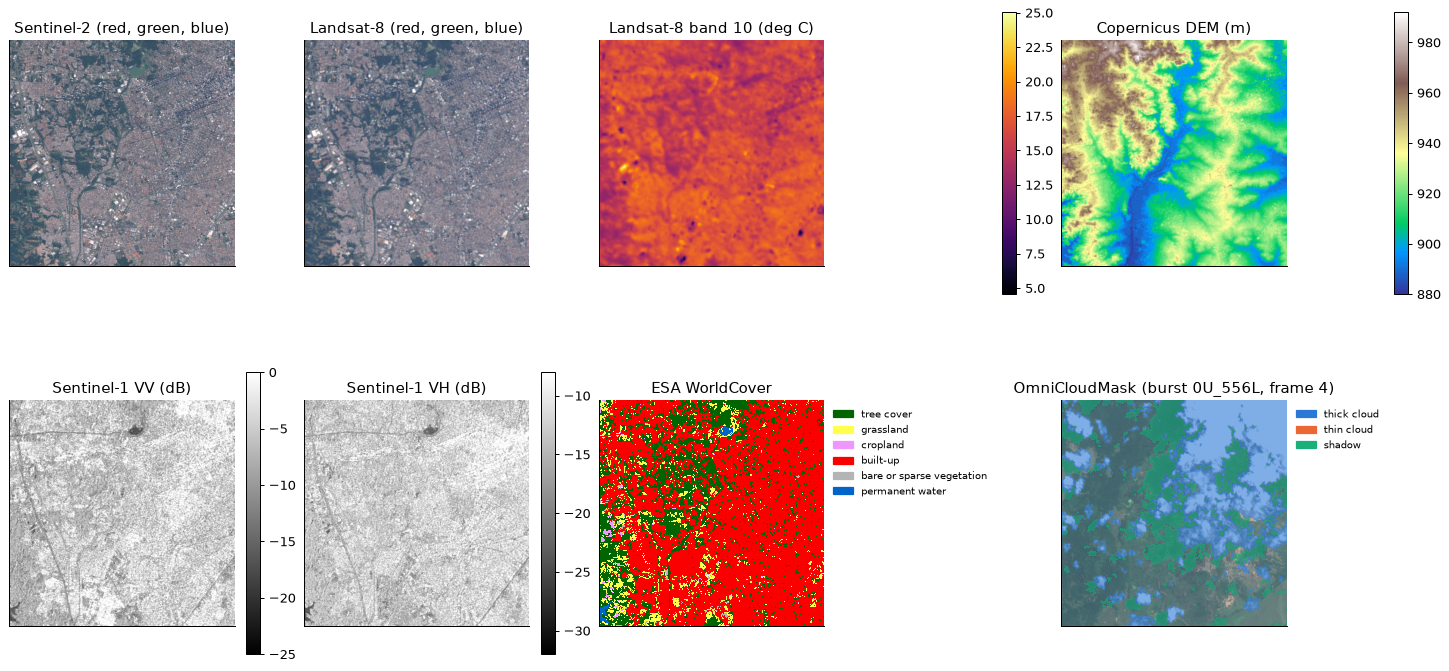

In [4]:
def rgb(cube, bands, gain=3.5):
    """True-colour quicklook from a reflectance cube."""
    img = np.stack([cube[b] for b in bands], -1).astype(np.float32) * 1e-4 * gain
    return np.clip(img, 0, 1) ** (1 / 1.4)


def db(x):
    return 10 * np.log10(np.where(x > 0, x, np.nan))


WC_COLOURS = {0: '#000000', 10: '#006400', 20: '#ffbb22', 30: '#ffff4c', 40: '#f096ff',
              50: '#fa0000', 60: '#b4b4b4', 70: '#f0f0f0', 80: '#0064c8', 90: '#0096a0',
              95: '#00cf75', 100: '#fae6a0'}
s2, l8, s1 = city.frame('s2'), city.frame('l8'), city.frame('s1')
dem, lc = city.read('dem'), city.read('lc')

fig, ax = plt.subplots(2, 4, figsize=(16, 8), layout='constrained')
ax[0, 0].imshow(rgb(s2, [3, 2, 1])); ax[0, 0].set_title('Sentinel-2 (red, green, blue)')
ax[0, 1].imshow(rgb(l8, [3, 2, 1])); ax[0, 1].set_title('Landsat-8 (red, green, blue)')
im = ax[0, 2].imshow(l8[9] * 1e-4 - 273.15, cmap='inferno')
ax[0, 2].set_title('Landsat-8 band 10 (deg C)'); fig.colorbar(im, ax=ax[0, 2], shrink=0.8)
im = ax[0, 3].imshow(dem, cmap='terrain'); ax[0, 3].set_title('Copernicus DEM (m)'); fig.colorbar(im, ax=ax[0, 3], shrink=0.8)
for k, pol in enumerate(['VV', 'VH']):
    im = ax[1, k].imshow(db(s1[k]), cmap='gray', vmin=-25 if k == 0 else -32, vmax=0 if k == 0 else -8)
    ax[1, k].set_title(f'Sentinel-1 {pol} (dB)'); fig.colorbar(im, ax=ax[1, k], shrink=0.8)
codes = sorted(WC_COLOURS)
ax[1, 2].imshow(np.searchsorted(codes, lc), cmap=ListedColormap([WC_COLOURS[c] for c in codes]),
                vmin=0, vmax=len(codes) - 1, interpolation='nearest')
ax[1, 2].set_title('ESA WorldCover')
present = [c for c in np.unique(lc) if c in et.factsheet.WC]
ax[1, 2].legend(handles=[Patch(color=WC_COLOURS[c], label=et.factsheet.WC[c]) for c in present],
                loc='upper left', bbox_to_anchor=(1, 1), fontsize=8, frameon=False)
# This city frame is 100% clear, so the mask is shown on a cloudy frame of a burst tile.
cloudy = et.tile('burst', 5)
mask = cloudy.frame('cloud_mask_s2', 4)
cloud_cols = ['#2a78d6', '#eb6834', '#1baf7a']          # thick cloud, thin cloud, shadow
ax[1, 3].imshow(rgb(cloudy.frame('s2', 4), [3, 2, 1]))
ax[1, 3].imshow(np.ma.masked_equal(mask, 0), cmap=ListedColormap(cloud_cols), vmin=1, vmax=3,
                interpolation='nearest', alpha=0.6)
ax[1, 3].set_title(f'OmniCloudMask (burst {cloudy.cell}, frame 4)')
ax[1, 3].legend(handles=[Patch(color=c, label=l) for c, l in
                         zip(cloud_cols, ['thick cloud', 'thin cloud', 'shadow'])],
                loc='upper left', bbox_to_anchor=(1, 1), fontsize=8, frameon=False)
for a in ax.flat:
    a.set_xticks([]); a.set_yticks([])

The OSM features that reach the model are chosen by size and role rules, merged by name, and projected into the tile through the S2 raster's own geotransform. Here they are over the image, with their 0-1000 boxes.

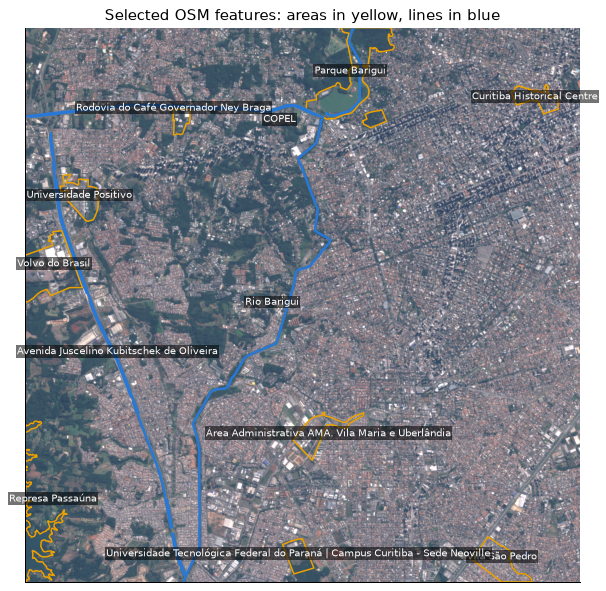

In [5]:
sheet = et.fact_sheet(city)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb(s2, [3, 2, 1]), extent=(0, 1, 1, 0))
for m in sheet.objects[:12]:
    g = m['geom']
    for part in getattr(g, 'geoms', [g]):
        if part.geom_type == 'Polygon':
            ax.plot(*part.exterior.xy, color='#eda100', lw=1.2)
        elif part.geom_type == 'LineString':
            ax.plot(*part.xy, color='#2a78d6', lw=2)
    x0, y0, x1, y1 = m['bbox']
    ax.text(np.clip((x0 + x1) / 2, 0.05, 0.95), np.clip((y0 + y1) / 2, 0.03, 0.97), m['name'],
            fontsize=8, ha='center', color='white',
            bbox=dict(facecolor='black', alpha=0.55, lw=0, pad=1))
ax.set_xlim(0, 1); ax.set_ylim(1, 0); ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Selected OSM features: areas in yellow, lines in blue');

## The fact sheet, and how it shrinks

Every line of the sheet is tagged with the modality that licenses it. A line with no tag (location, land cover, OSM) is true whatever the encoder sees.

In [6]:
print('\n'.join(textwrap.fill(line, 110, subsequent_indent='    ')
                for line in sheet.text().splitlines()))

GRID CELL 284D_496L  centre -25.4641, -49.3171  EPSG:32722  1056x1056 px at 10 m (10.56 x 10.56 km)
LOCATION Curitiba, Região Geográfica Imediata de Curitiba, Região Metropolitana de Curitiba, Região Geográfica
    Intermediária de Curitiba, Paraná, South Region, Brazil  [tile spans 33 units at level 10 (Campo Comprido,
    Novo Mundo, Portão, ...)]
ACQUIRED 2021-05-24  solar elevation 37 deg
WEATHER AT OVERPASS (ERA5) 10 C, 66% RH, 0.0 mm precip, wind 23 km/h, ERA5 cloud cover 27%
SETTLEMENT AND CLIMATE CONTEXT heavily modified by human activity; long-term mean annual temperature about 18
    C
LAND COVER (ESA WorldCover) built-up 68%; tree cover 23%; grassland 7%
ELEVATION (Copernicus DEM) 880 to 992 m (median 924 m, relief 112 m)
CLOUD (OmniCloudMask, Sentinel-2) clear 100%, thick cloud 0%, thin cloud 0%, shadow 0%
SPECTRAL (Sentinel-2, cloud-masked) vegetation index NDVI mean +0.30 (10th-90th pct +0.07 to +0.66); surface
    fractions: vegetated 41% (densely 15%), open water 1%, un

Removing a modality removes its lines and nothing else.

In [7]:
configs = {'all': {'s2', 'l8', 's1', 'dem', 'lc'}, 'S2 + DEM': {'s2', 'dem'},
           'S2 only': {'s2'}, 'no imagery': set()}
pd.DataFrame([{'input': k, 'lines': len(sheet.text(v).splitlines()),
               'characters': len(sheet.text(v)),
               'tags kept': ', '.join(sorted({m for m, _ in sheet.blocks if m and m in v}))}
              for k, v in configs.items()]).set_index('input')

,lines,characters,tags kept
input,,,
all,14,3397,"dem, l8, s1, s2"
S2 + DEM,12,2982,"dem, s2"
S2 only,11,2913,s2
no imagery,9,2443,


What S2 alone adds to the untagged lines:

In [8]:
untagged = set(sheet.text(set()).splitlines())
for line in sheet.text({'s2'}).splitlines():
    if line not in untagged:
        print(textwrap.fill(line, 110, subsequent_indent='    '))

CLOUD (OmniCloudMask, Sentinel-2) clear 100%, thick cloud 0%, thin cloud 0%, shadow 0%
SPECTRAL (Sentinel-2, cloud-masked) vegetation index NDVI mean +0.30 (10th-90th pct +0.07 to +0.66); surface
    fractions: vegetated 41% (densely 15%), open water 1%, unvegetated and SWIR-bright (bare ground or sealed
    surfaces) 40%; vegetation gradient: greenest in the north, least green in the north-east; unvegetated
    surfaces: most concentrated in the south-east, least in the north


## Every task family

Sixteen families, each with an answer shape, the modalities it requires, and how well a frozen decoder emits that shape.

In [9]:
pd.DataFrame(et.registry_table()).set_index('family')

,shape,frozen_llm_feasibility,max_target_tokens,requires,chain_stage
family,,,,,
caption,prose,high,180,—,3
dominant_cover,word,high,8,lc,3
which_present,choice,high,12,—,3
locate_point,point,high,30,—,2
locate_bbox,bbox,high,40,—,2
features_all,points_multi,low,200,—,1
ndvi_grid,grid,low,400,s2,1
cover_grid,grid,low,400,lc,1
vegetated_fraction,derived,high,48,s2,2


Three tiles cover every family: the city (single date), a monthly climatology in Kenya and a burst in the Amazon delta.

In [10]:
monthly = et.tile('monthly', 352)
burst = et.tile('burst', 5)
caption = ('Curitiba fills the centre of the tile, a dense city with green parks, '
           'ringed by farmland and forest.')
examples = {}
for t in (city, monthly, burst):
    for e in et.examples_for(t, caption=caption if t is city else None):
        examples.setdefault(e.family, (t, e))


def short(s, n=230):
    return s if len(s) <= n else s[:n] + ' ...'


for fam in et.FAMILIES:
    t, e = examples[fam]
    print(f'[{fam}]  {t.part.name} {t.cell}\n  Q: {short(e.question)}\n  A: {short(e.target)}\n')

[caption]  monotemporal 284D_496L
  Q: Describe the area covered here. Answer in two to four sentences of plain prose.
  A: Curitiba fills the centre of the tile, a dense city with green parks, ringed by farmland and forest.

[dominant_cover]  monotemporal 284D_496L
  Q: What covers most of the ground in this image? Answer with exactly one name copied from the list, and nothing else. Options: cropland; built-up; permanent water; grassland; tree cover; mangroves.
  A: built-up

[which_present]  monotemporal 284D_496L
  Q: Pick the feature that actually appears in this tile. Answer with one option copied exactly, and nothing else. Options: Volvo do Brasil; Kalgoorlie Consolidated Gold Mines; Puerto Miranda Ferry Terminal; Zaragoza Delicias Station.
  A: Volvo do Brasil

[locate_point]  monotemporal 284D_496L
  Q: Indicate where Área Administrativa AMA. Vila Maria e Uberlândia is. Answer only JSON: {"point_2d":[x,y],"label":"..."}, with x and y integers from 0 to 1000 measured across and 

The spatial targets are integers on a 0-1000 grid. Here are the box and the point of two features, and an NDVI grid at the size its prompt asked for.

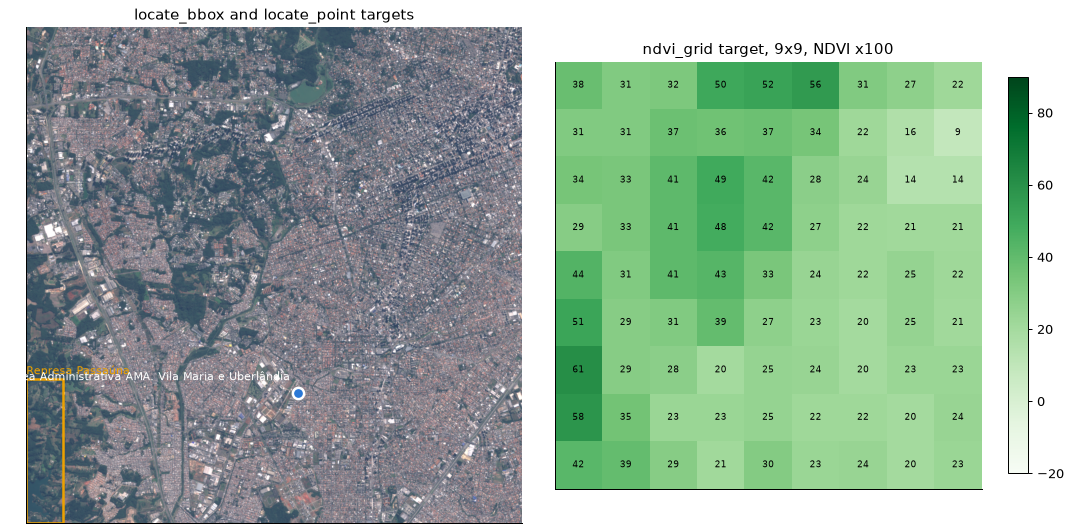

In [11]:
box = json.loads(examples['locate_bbox'][1].target)
pt = json.loads(examples['locate_point'][1].target)
grid = json.loads(examples['ndvi_grid'][1].target)
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].imshow(rgb(s2, [3, 2, 1]), extent=(0, 1000, 1000, 0))
x0, y0, x1, y1 = box['bbox_2d']
ax[0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, color='#eda100', lw=2))
ax[0].text(x0, y0 - 10, box['label'], color='#eda100', fontsize=9)
ax[0].plot(*pt['point_2d'], 'o', ms=9, mfc='#2a78d6', mec='white', mew=2)
ax[0].text(pt['point_2d'][0] - 15, pt['point_2d'][1] - 25, pt['label'], color='white',
           fontsize=9, ha='right' if pt['point_2d'][0] > 500 else 'left')
ax[0].set_title('locate_bbox and locate_point targets')
g = np.array(grid['grid'], dtype=float)
im = ax[1].imshow(g, cmap='Greens', vmin=-20, vmax=90)
for (r, c), v in np.ndenumerate(g):
    ax[1].text(c, r, '' if np.isnan(v) else int(v), ha='center', va='center', fontsize=7)
ax[1].set_title(f'ndvi_grid target, {grid["shape"][0]}x{grid["shape"][1]}, NDVI x100')
fig.colorbar(im, ax=ax[1], shrink=0.8)
for a in ax:
    a.set_xticks([]); a.set_yticks([])
fig.tight_layout()

## The temporal families

A monthly tile is a climatology: one frame per calendar month, drawn from several years. A burst is a few weeks at a five-day cadence. The series facts read the dates, not the part name, to tell the two apart.

In [12]:
for t in (monthly, burst):
    sf = et.series_facts(t)
    print(f'{t.part.name} {t.cell}: {sf.kind.value}, {sf.n_frames} frames over {sf.span_days} days')
    print(textwrap.fill(et.temporal_block(sf), 110), '\n')

monthly 11U_389R: climatology, 12 frames over 3470 days
SERIES (Sentinel-2) a seasonal composite: 12 acquisitions, roughly one per calendar month but drawn from 9
different years, so it describes the TYPICAL year and not any single one; 11 of 12 frames are clear enough to
read (July obscured); vegetation typically peaks in June and is lowest in March (NDVI +0.26 to +0.61); 28% of
the tile is much darker in the burn ratio in January than in the preceding month, a seasonal contrast rather
than a dated event; air temperature at overpass runs 18 C in July to 25 C in April 

burst 0U_556L: burst, 6 frames over 25 days
SERIES (Sentinel-2) a burst: 6 acquisitions over 25 days; 4 of 6 frames are clear enough to read (28 July
2019, 7 August 2019 obscured); 12% of the tile dropped past the burn-severity threshold by 2 August 2019,
consistent with fire, flood or clearance inside this window; air temperature at overpass runs 28 C on 18 July
2019 to 30 C on 12 August 2019 



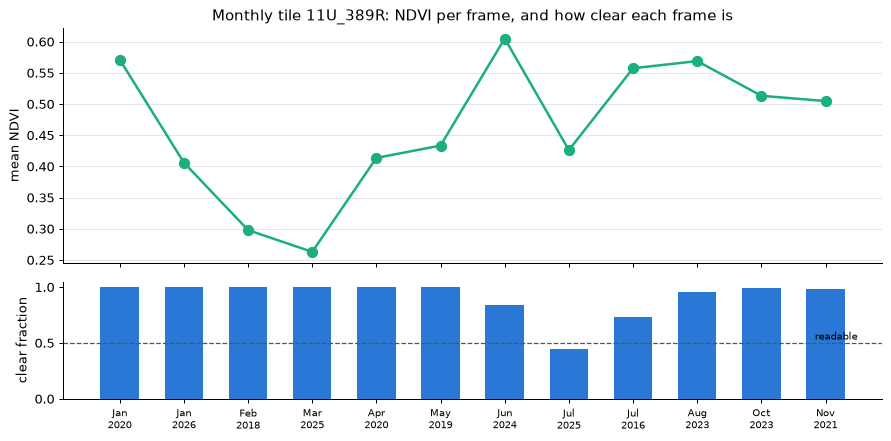

In [13]:
sf = et.series_facts(monthly)
order = sorted(range(sf.n_frames), key=lambda i: sf.dates[i][5:])
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True, height_ratios=[2, 1])
x = np.arange(len(order))
ax[0].plot(x, [sf.ndvi[i] for i in order], '-o', color='#1baf7a', lw=2, ms=8)
ax[0].set_ylabel('mean NDVI'); ax[0].grid(axis='y', color='#dddddd', lw=0.6)
ax[0].set_title(f'Monthly tile {monthly.cell}: NDVI per frame, and how clear each frame is')
ax[1].bar(x, [sf.clear[i] for i in order], color='#2a78d6', width=0.6)
ax[1].axhline(et.temporal.FRAME_CLEAR_MIN, color='#555555', lw=1, ls='--')
ax[1].text(len(order) - 0.5, et.temporal.FRAME_CLEAR_MIN + 0.03, 'readable', ha='right', fontsize=8)
ax[1].set_ylabel('clear fraction'); ax[1].set_ylim(0, 1.05)
ax[1].set_xticks(x, [f'{et.temporal.MONTHS[int(sf.dates[i][5:7]) - 1][:3]}\n{sf.dates[i][:4]}'
                     for i in order], fontsize=8)
fig.tight_layout()

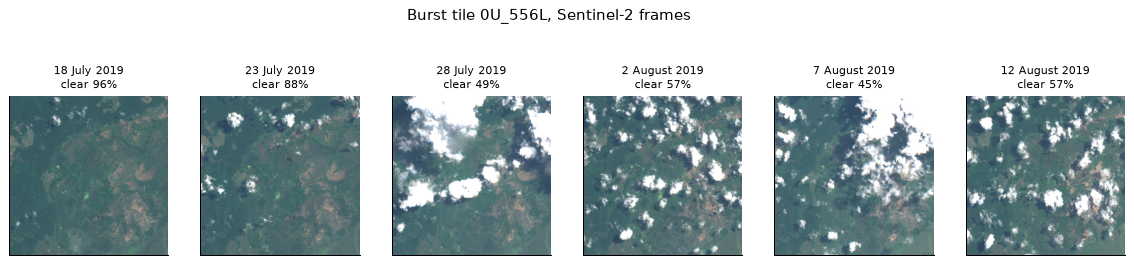

In [14]:
stack, masks = burst.read('s2'), burst.read('cloud_mask_s2')
sb = et.series_facts(burst)
fig, ax = plt.subplots(1, stack.shape[0], figsize=(16, 3.4))
for i, a in enumerate(ax):
    a.imshow(rgb(stack[i], [3, 2, 1]))
    a.set_title(f'{sb.day_of(i)}\nclear {sb.clear[i]:.0%}', fontsize=9)
    a.set_xticks([]); a.set_yticks([])
fig.suptitle(f'Burst tile {burst.cell}, Sentinel-2 frames', y=1.04);

## A multi-turn conversation

`ElliotTaskDataset` yields the arrays of the modalities you ask for and a conversation over them. Here the encoder gets only S2 and the DEM, so no question about radar, thermal or land cover is asked.

In [15]:
from elliot_tasks.torch import ElliotTaskDataset

ds = ElliotTaskDataset('monthly', [352], available=('s2', 'dem'), epoch=0, seed=0)
arrays, conversation = ds[0]
print({k: tuple(v.shape) for k, v in arrays.items()}, '\n')
for turn in conversation:
    print(f'{turn["role"]:>9}: {short(turn["content"], 300)}')

{'s2': (12, 13, 1056, 1056), 'dem': (1056, 1056)} 

     user: Identify the position of every named feature. Answer only JSON: {"points_2d":[[x,y],...],"label":"..."}, with integers from 0 to 1000, one point per feature. The named features are: Kitale; Section 6 Forest; ShowGround Forest; KCC Forest; Kitale Golf Club; Namanjalala Market; Kitale National Polytec ...
assistant: {"points_2d":[[526,104],[636,484],[712,597],[549,630],[465,707],[719,696],[800,709],[592,816]],"label":"named features"}
     user: Trace vegetation through this series. Answer only a JSON array of numbers. There are 12 acquisitions, in order: January, January, February, March, April, May, June, July, July, August, October, November. Give NDVI multiplied by 100 and rounded to a whole number for each, as a JSON array, using null  ...
assistant: [57,41,30,26,41,43,61,43,56,57,51,50]
     user: Report date and illumination geometry. Answer only a JSON object with the named keys. Use the keys "date" (YYYY-MM-DD) and "

The seed is a function of the cell and the epoch: the same epoch gives the same conversation, the next one resamples the wording and the tasks.

In [16]:
same = ds[0][1] == conversation
ds.set_epoch(1)
print('same epoch identical:', same, '| epoch 1 differs:', ds[0][1] != conversation)

same epoch identical: True | epoch 1 differs: True


## Scoring answers

Each shape has a parser and a scorer. Every score reports whether the answer parsed, whether it is well formed, and how right it is on [0, 1].

In [17]:
def show(family, answers):
    t, e = examples[family]
    print(f'[{family}] target: {short(e.target, 120)}')
    for a in answers:
        s = et.score(e, a)
        print(f'   {short(a, 60):<62} parsed={s.parsed!s:<5} wellformed={s.wellformed!s:<5} '
              f'score={s.score if s.score is None else round(s.score, 2)}  {s.details}')
    print()


box = json.loads(examples['locate_bbox'][1].target)['bbox_2d']
show('locate_bbox', [json.dumps({'bbox_2d': [box[0], box[1] + 20, box[2] + 15, box[3] - 10]}),
                     '{"bbox_2d": [0, 0, 1000, 1000]}', 'It is in the south-west.'])
show('dominant_cover', ['Built-up.', 'urban', 'tree cover'])
show('relief', ['120', 'about 112 metres', '300'])
show('vegetated_fraction', ['{"ndvi_x100":[30,33,27],"vegetated_percent":45}',
                            '{"ndvi_x100":[60,60,60],"vegetated_percent":80}'])
show('disturbance', [examples['disturbance'][1].target,
                     '{"changed_percent":[0,0,0],"date":"18 July 2019"}'])

[locate_bbox] target: {"bbox_2d":[0,710,75,1000],"label":"Represa Passaúna"}
   {"bbox_2d": [0, 730, 90, 990]}                                 parsed=True  wellformed=True  score=0.76  {'iou': 0.7602339181286549, 'hit': True}
   {"bbox_2d": [0, 0, 1000, 1000]}                                parsed=True  wellformed=True  score=0.02  {'iou': 0.02175, 'hit': False}
   It is in the south-west.                                       parsed=False wellformed=False score=0.0  {}

[dominant_cover] target: built-up
   Built-up.                                                      parsed=True  wellformed=True  score=1.0  {'answer': 'built up'}
   urban                                                          parsed=True  wellformed=False score=0.0  {'answer': 'urban'}
   tree cover                                                     parsed=True  wellformed=True  score=0.0  {'answer': 'tree cover'}

[relief] target: 112
   120                                                            parsed=True  